In [119]:
import json
import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

# ============================================================
# User config
# ============================================================
# Keep the notebook-local PT path and the selected_worker_file
# path rewrite that you already added.
BATCH_PT_PATH = Path("./batch_request_characteristics.pt")
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

METHOD = "speculative"
ROUND_LIMIT = 20
CONF_BINS = np.linspace(0.0, 1.0, 11)

# If None, use all datasets available for METHOD
DATASET_ORDER = None

OLD_PREFIX = "/scratch/junsuk87/vllm-sampling/"
NEW_PREFIX = "./"

# ============================================================
# Style
# Match plot_motivation.ipynb sizing/style convention
# ============================================================
FIGSIZE = (6, 4)

LABEL_FS = 12
TICK_FS = 12
LEGEND_FS = 10
ANNOT_FS = 12

sns.set_palette("tab10")
sns.set_style("whitegrid")
palette = sns.color_palette("tab10")

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.size"] = LABEL_FS
mpl.rcParams["axes.labelsize"] = LABEL_FS
mpl.rcParams["xtick.labelsize"] = TICK_FS
mpl.rcParams["ytick.labelsize"] = TICK_FS
mpl.rcParams["legend.fontsize"] = LEGEND_FS

BLUE = palette[0]
ORANGE = palette[1]
GREEN = palette[2]
RED = palette[3]

print("cwd:", Path.cwd())

cwd: /Users/junsu/EECE571/vllm-nips26


In [120]:
# ============================================================
# Helpers
# ============================================================
def setup_figure(figsize=FIGSIZE, bottom=0.32, top=0.84):
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=False)
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        bottom=bottom,
        top=top,
    )
    return fig, ax


def setup_figure_grid(nrows, ncols, figsize=FIGSIZE, bottom=0.20, top=0.86, wspace=0.35, hspace=0.50):
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        squeeze=False,
        constrained_layout=False,
    )
    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        bottom=bottom,
        top=top,
        wspace=wspace,
        hspace=hspace,
    )
    return fig, axes


def style_axes(ax, ygrid=True, xgrid=False):
    ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
    ax.grid(ygrid, axis="y", linestyle=":", linewidth=0.8)
    ax.grid(xgrid, axis="x", linestyle=":", linewidth=0.8)
    ax.set_axisbelow(True)


def load_batch_artifact(pt_path: Path):
    obj = torch.load(pt_path, map_location="cpu", weights_only=False)
    records = obj["records"]

    # Keep the path rewrite you added in plot_analysis.ipynb.
    for r in records:
        if "selected_worker_file" in r and isinstance(r["selected_worker_file"], str):
            r["selected_worker_file"] = r["selected_worker_file"].replace(
                OLD_PREFIX, NEW_PREFIX
            )

    df = pd.DataFrame(records)
    return obj, df


def read_jsonl(path):
    rows = []
    path = Path(path)
    if not path.exists():
        print(f"Warning: File not found -> {path}")
        return rows

    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def filter_method_df(df, method=METHOD):
    return df[df["method"] == method].copy()


def get_dataset_order(df, preferred=None):
    available = sorted(df["dataset"].dropna().unique().tolist())
    if preferred is None:
        return available
    return [x for x in preferred if x in available]


def get_single_record(df, dataset, batch_size, num_spec_tokens=None):
    sub = df[
        (df["dataset"] == dataset) &
        (df["batch_size"] == batch_size)
    ].copy()

    if num_spec_tokens is not None:
        sub = sub[sub["num_speculative_tokens"] == num_spec_tokens].copy()

    if len(sub) == 0:
        return None

    sub = sub.sort_values(["num_speculative_tokens", "selected_worker_id", "selected_worker_file"])
    return sub.iloc[0].to_dict()


def choose_representative_request_trace(record, round_limit=ROUND_LIMIT):
    rows = read_jsonl(record["selected_worker_file"])
    if not rows:
        return None, pd.DataFrame()

    req_to_rows = {}
    for row in rows:
        rid = row["req_id"]
        req_to_rows.setdefault(rid, []).append(row)

    best_req_id = None
    best_trace = None

    for rid, trace_rows in sorted(req_to_rows.items()):
        trace_rows = sorted(trace_rows, key=lambda x: int(x["step_id"]))
        if len(trace_rows) >= round_limit:
            best_req_id = rid
            best_trace = trace_rows[:round_limit]
            break

    if best_trace is None:
        ranked = sorted(
            req_to_rows.items(),
            key=lambda kv: (-len(kv[1]), kv[0]),
        )
        best_req_id, trace_rows = ranked[0]
        best_trace = sorted(trace_rows, key=lambda x: int(x["step_id"]))[:round_limit]

    trace_df = pd.DataFrame(best_trace).copy()
    trace_df["round_index"] = np.arange(len(trace_df))
    trace_df["acceptance_length"] = trace_df["num_accepted_tokens"].astype(int)
    trace_df["is_misspec"] = trace_df["acceptance_length"] == 0
    return best_req_id, trace_df


def histogram_to_probability(hist_dict):
    if hist_dict is None:
        return pd.DataFrame(columns=["acceptance_length", "probability", "count"])
    items = sorted((int(k), int(v)) for k, v in hist_dict.items())
    total = sum(v for _, v in items)
    if total == 0:
        return pd.DataFrame(columns=["acceptance_length", "probability", "count"])
    return pd.DataFrame({
        "acceptance_length": [k for k, _ in items],
        "count": [v for _, v in items],
        "probability": [v / total for _, v in items],
    })


def extract_match_probabilities(record):
    topk = record["topk_match_probability_under_misspeculation"]
    return pd.DataFrame({
        "topk": ["top_2", "top_3", "top_4", "top_5"],
        "probability": [
            topk.get("top_2", {}).get("probability", None),
            topk.get("top_3", {}).get("probability", None),
            topk.get("top_4", {}).get("probability", None),
            topk.get("top_5", {}).get("probability", None),
        ],
    })


def pearson_corr_safe(x, y):
    if len(x) < 2:
        return np.nan
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.allclose(x.std(), 0.0) or np.allclose(y.std(), 0.0):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def build_confidence_mismatch_df(record):
    rows = read_jsonl(record["selected_worker_file"])
    out = []

    for row in rows:
        confs = row.get("first_draft_topk_confidences")
        if not isinstance(confs, list) or len(confs) == 0:
            continue

        first_conf = confs[0]
        if first_conf is None:
            continue

        acceptance_length = int(row.get("num_accepted_tokens", 0))
        out.append({
            "confidence": float(first_conf),
            "mismatch": 1 if acceptance_length == 0 else 0,
            "acceptance_length": acceptance_length,
            "step_id": int(row.get("step_id", -1)),
            "req_id": row.get("req_id"),
        })

    return pd.DataFrame(out)


def build_binned_mismatch_curve(df_conf, bins=CONF_BINS):
    if len(df_conf) == 0:
        return pd.DataFrame(columns=["bin_left", "bin_right", "bin_center", "mismatch_probability", "count"])

    df_conf = df_conf.copy()
    df_conf["bin"] = pd.cut(df_conf["confidence"], bins=bins, include_lowest=True, right=True)

    grouped = (
        df_conf.groupby("bin", observed=False)
        .agg(
            mismatch_probability=("mismatch", "mean"),
            count=("mismatch", "size"),
        )
        .reset_index()
    )

    grouped["bin_left"] = grouped["bin"].apply(lambda x: float(x.left))
    grouped["bin_right"] = grouped["bin"].apply(lambda x: float(x.right))
    grouped["bin_center"] = (grouped["bin_left"] + grouped["bin_right"]) / 2.0
    return grouped

In [121]:
# ============================================================
# Load
# ============================================================
artifact, batch_df_all = load_batch_artifact(BATCH_PT_PATH)
METHOD = "speculative"
batch_df = filter_method_df(batch_df_all, METHOD)

datasets = get_dataset_order(batch_df, preferred=DATASET_ORDER)

print("artifact type:", artifact["type"])
print("available methods:", artifact["stats"]["methods"])
print("available datasets for method:", datasets)
print("available batch sizes:", sorted(batch_df["batch_size"].dropna().unique().tolist()))
print("available num_speculative_tokens:", sorted(batch_df["num_speculative_tokens"].dropna().unique().tolist()))

artifact type: batch_request_characteristics
available methods: ['eagle3', 'magicdec', 'pivot', 'speculative', 'tetris']
available datasets for method: ['aime25']
available batch sizes: [1, 4, 16, 64, 256]
available num_speculative_tokens: [3, 5, 7]


/var/folders/d6/bt54rcvj3r5119qfm5079ybh0000gn/T/ipykernel_63671/2428907104.py:37: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(xgrid, axis="x", linestyle=":", linewidth=0.8)


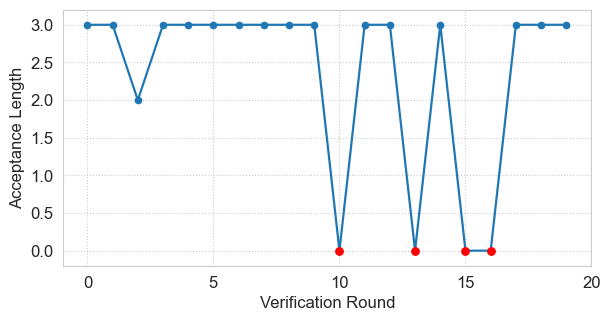

In [122]:
# ============================================================
# Figure 1
# batch_size = 1
# One representative request trace per dataset up to 20 rounds
# ============================================================
records_bs1 = {}
for dataset in datasets:
    rec = get_single_record(batch_df, dataset=dataset, batch_size=1)
    if rec is not None:
        records_bs1[dataset] = rec

n = len(records_bs1)
ncols = min(3, max(1, n))
nrows = max(1, math.ceil(n / ncols))

fig, axes = setup_figure_grid(nrows, ncols, figsize=FIGSIZE, bottom=0.22, top=0.86, wspace=0.40, hspace=0.70)
axes_flat = axes.flatten()

for ax, dataset in zip(axes_flat, records_bs1.keys()):
    req_id, trace_df = choose_representative_request_trace(records_bs1[dataset], round_limit=ROUND_LIMIT)

    if trace_df.empty:
        ax.text(0.5, 0.5, f"{dataset}\nNo trace found", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.plot(
        trace_df["round_index"],
        trace_df["acceptance_length"],
        marker="o",
        linewidth=1.6,
        markersize=4.5,
        color=BLUE,
    )

    miss = trace_df[trace_df["is_misspec"]]
    if len(miss) > 0:
        ax.scatter(
            miss["round_index"],
            miss["acceptance_length"],
            color="red",
            s=28,
            zorder=5,
        )

    max_accept = int(trace_df["acceptance_length"].max()) if len(trace_df) else 1
    ax.set_xlabel("Verification Round")
    ax.set_ylabel("Acceptance Length")
    ax.set_xticks(np.arange(0, ROUND_LIMIT + 1, 5))
    ax.set_ylim(-0.2, max(3, max_accept) + 0.2)
    style_axes(ax, ygrid=True, xgrid=False)

for ax in axes_flat[n:]:
    ax.set_axis_off()

fig.savefig(PLOTS_DIR / f"batchchar_fig1_acceptance_trace_{METHOD}.pdf")
fig.savefig(PLOTS_DIR / f"batchchar_fig1_acceptance_trace_{METHOD}.png", dpi=600)
plt.show()

/var/folders/d6/bt54rcvj3r5119qfm5079ybh0000gn/T/ipykernel_63671/2428907104.py:37: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(xgrid, axis="x", linestyle=":", linewidth=0.8)


21    0.191394
22    0.200436
23    0.213652
Name: misspeculation_probability, dtype: float64
0.20182733333333336


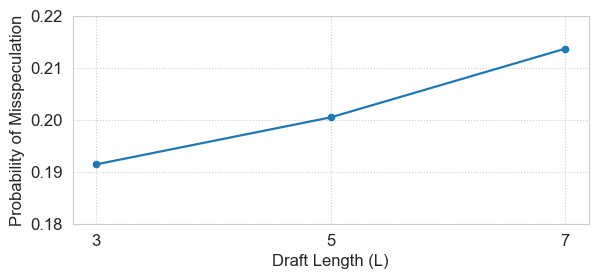

In [123]:
# ============================================================
# Figure 2
# batch_size = 256
# misspeculation probability vs num_speculative_tokens
# Keep the xticks change you made: 3, 5, 7
# ============================================================
fig, ax = setup_figure(figsize=FIGSIZE, bottom=0.32, top=0.84)
temp = 0
for dataset in datasets:
    sub = (
        batch_df[
            (batch_df["dataset"] == dataset) &
            (batch_df["batch_size"] == 256)
        ]
        .sort_values("num_speculative_tokens")
    )
    if len(sub) == 0:
        continue

    ax.plot(
        sub["num_speculative_tokens"],
        sub["misspeculation_probability"],
        marker="o",
        linewidth=1.6,
        markersize=4.5,
        label=dataset,
    )
    
    print(sub["misspeculation_probability"])
    

mean = (0.191394 + 0.200436 + 0.213652) / 3
print(mean)
ax.set_xticks([3, 5, 7])
ax.set_xticklabels([3, 5, 7])
ax.set_xlabel("Draft Length (L)")
ax.set_ylabel("Probability of Misspeculation")
ax.set_ylim(0.18, 0.22)
style_axes(ax, ygrid=True, xgrid=False)

fig.savefig(PLOTS_DIR / f"batchchar_fig2_misspec_vs_k_{METHOD}.pdf")
fig.savefig(PLOTS_DIR / f"batchchar_fig2_misspec_vs_k_{METHOD}.png", dpi=600)
plt.show()

0    0.191394
1    0.136433
2    0.099652
3    0.572521
Name: probability, dtype: float64


/var/folders/d6/bt54rcvj3r5119qfm5079ybh0000gn/T/ipykernel_63671/2428907104.py:37: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(xgrid, axis="x", linestyle=":", linewidth=0.8)


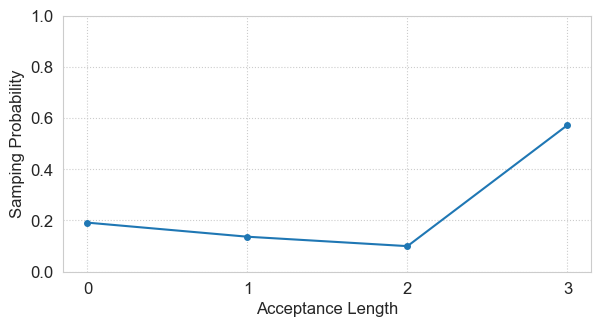

In [124]:
# ============================================================
# Figure 3
# batch_size = 256
# acceptance length distribution per dataset
# ============================================================
records_bs256 = {}
for dataset in datasets:
    rec = get_single_record(batch_df, dataset=dataset, batch_size=256)
    if rec is not None:
        records_bs256[dataset] = rec

n = len(records_bs256)
ncols = min(3, max(1, n))
nrows = max(1, math.ceil(n / ncols))

fig, axes = setup_figure_grid(nrows, ncols, figsize=FIGSIZE, bottom=0.22, top=0.86, wspace=0.45, hspace=0.70)
axes_flat = axes.flatten()

for ax, dataset in zip(axes_flat, records_bs256.keys()):
    hist_df = histogram_to_probability(records_bs256[dataset]["acceptance_length_histogram_global"])
    ax.plot(
        hist_df["acceptance_length"],
        hist_df["probability"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        color=BLUE,
    )
    print(hist_df["probability"])
    ax.set_xlabel("Acceptance Length")
    ax.set_ylabel("Samping Probability")
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels([0, 1, 2, 3])
    ax.set_ylim(0, 1.0)
    style_axes(ax, ygrid=True, xgrid=False)

for ax in axes_flat[n:]:
    ax.set_axis_off()

fig.savefig(PLOTS_DIR / f"batchchar_fig3_acceptance_dist_b256_{METHOD}.pdf")
fig.savefig(PLOTS_DIR / f"batchchar_fig3_acceptance_dist_b256_{METHOD}.png", dpi=600)
plt.show()

    topk  probability dataset
0  top_2     0.000592  aime25
1  top_3     0.002367  aime25
2  top_4     0.002367  aime25
3  top_5     0.003550  aime25
[DEBUG] dataset=aime25, ys=[np.float64(0.000591715976331361), np.float64(0.002366863905325444), np.float64(0.002366863905325444), np.float64(0.0035502958579881655)]


/var/folders/d6/bt54rcvj3r5119qfm5079ybh0000gn/T/ipykernel_63671/2428907104.py:37: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(xgrid, axis="x", linestyle=":", linewidth=0.8)


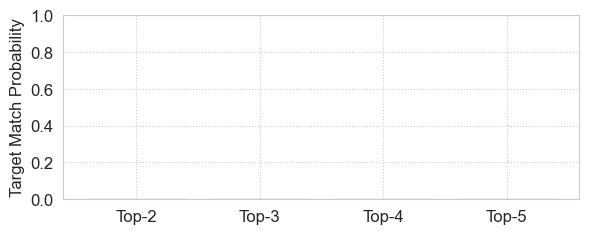

In [125]:
# ============================================================
# Figure 4
# batch_size = 1
# target match probability under misspeculation for top-2,3,4,5
# ============================================================
# Need to debug, should be 90%

match_rows = []
for dataset in datasets:
    rec = get_single_record(batch_df, dataset=dataset, batch_size=1)
    if rec is None:
        print(f"[WARN] no record found for dataset={dataset}, batch_size=1")
        continue

    sub = extract_match_probabilities(rec)
    sub["dataset"] = dataset
    match_rows.append(sub)

match_df = pd.concat(match_rows, ignore_index=True) if match_rows else pd.DataFrame()

print(match_df)  # 디버깅용

fig, ax = setup_figure(figsize=FIGSIZE, bottom=0.34, top=0.80)

topk_order = ["top_2", "top_3", "top_4", "top_5"]
topk_labels = ["Top-2", "Top-3", "Top-4", "Top-5"]

x = np.arange(len(topk_order))
bar_width = 0.8 / max(1, len(datasets))

for i, dataset in enumerate(datasets):
    ys = []
    for tk in topk_order:
        val = match_df[
            (match_df["dataset"] == dataset) &
            (match_df["topk"] == tk)
        ]["probability"]
        ys.append(val.iloc[0] if len(val) > 0 else np.nan)

    print(f"[DEBUG] dataset={dataset}, ys={ys}")  # 디버깅용

    ax.bar(
        x + (i - (len(datasets) - 1) / 2) * bar_width,
        ys,
        width=bar_width,
        edgecolor="black",
        linewidth=0.8,
        label=dataset,
    )

ax.set_xticks(x)
ax.set_xticklabels(topk_labels)
ax.set_ylabel("Target Match Probability")
ax.set_ylim(0, 1.0)

style_axes(ax, ygrid=True)


fig.savefig(PLOTS_DIR / f"batchchar_fig4_target_match_{METHOD}.pdf")
fig.savefig(PLOTS_DIR / f"batchchar_fig4_target_match_{METHOD}.png", dpi=600)
plt.show()

Confidence vs misspeculation correlation


,dataset,num_points,num_misspeculation,misspeculation_probability,pearson_corr
0,aime25,9255,1690,0.182604,-0.17525


/var/folders/d6/bt54rcvj3r5119qfm5079ybh0000gn/T/ipykernel_63671/2428907104.py:37: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(xgrid, axis="x", linestyle=":", linewidth=0.8)


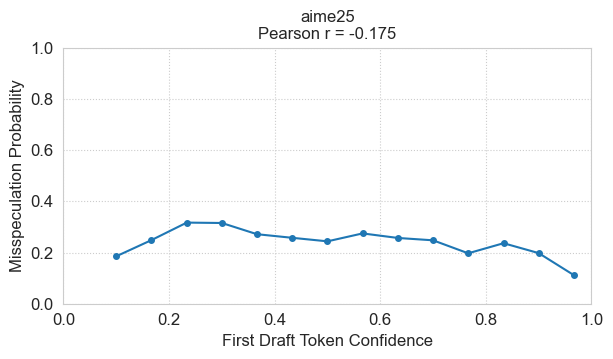

In [127]:
# ============================================================
# Figure 5
# batch_size = 1
# misspeculation probability vs first draft token confidence
# Uses rec["confidence_mismatch_rows"] from the updated aggregate artifact
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CONF_BINS = np.linspace(0.0, 1.0, 16)

def build_confidence_mismatch_df(rec):
    rows = rec.get("confidence_mismatch_rows", [])
    if not rows:
        return pd.DataFrame(columns=[
            "step_id", "req_id", "req_index",
            "confidence", "acceptance_length", "mismatch"
        ])

    df = pd.DataFrame(rows).copy()
    if df.empty:
        return pd.DataFrame(columns=[
            "step_id", "req_id", "req_index",
            "confidence", "acceptance_length", "mismatch"
        ])

    df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")
    df["acceptance_length"] = pd.to_numeric(df["acceptance_length"], errors="coerce")
    df["mismatch"] = pd.to_numeric(df["mismatch"], errors="coerce")

    df = df[np.isfinite(df["confidence"])]
    df = df[(df["confidence"] >= 0.0) & (df["confidence"] <= 1.0)]
    df = df.sort_values(["confidence", "step_id", "req_id"], ignore_index=True)
    return df


def build_binned_mismatch_curve(df_conf, bins=CONF_BINS):
    if df_conf.empty:
        return pd.DataFrame(columns=[
            "bin", "count", "mismatch_probability",
            "bin_left", "bin_right", "bin_center"
        ])

    out = df_conf.copy()
    out["bin"] = pd.cut(
        out["confidence"],
        bins=bins,
        include_lowest=True,
        duplicates="drop",
    )

    grouped = (
        out.groupby("bin", observed=False)
        .agg(
            count=("mismatch", "size"),
            mismatch_probability=("mismatch", "mean"),
        )
        .reset_index()
    )

    if len(grouped) == 0:
        return pd.DataFrame(columns=[
            "bin", "count", "mismatch_probability",
            "bin_left", "bin_right", "bin_center"
        ])

    intervals = pd.IntervalIndex(grouped["bin"])
    grouped["bin_left"] = intervals.left.astype(float)
    grouped["bin_right"] = intervals.right.astype(float)
    grouped["bin_center"] = (grouped["bin_left"] + grouped["bin_right"]) / 2.0
    grouped = grouped[grouped["count"] > 0].reset_index(drop=True)
    return grouped


def pearson_corr_safe(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if np.isclose(x.std(ddof=0), 0.0) or np.isclose(y.std(ddof=0), 0.0):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


corr_rows = []
curve_dict = {}

for dataset in datasets:
    rec = get_single_record(batch_df, dataset=dataset, batch_size=1)
    if rec is None:
        print(f"[SKIP] {dataset}: no record")
        continue

    conf_df = build_confidence_mismatch_df(rec)
    if conf_df.empty:
        print(f"[SKIP] {dataset}: no confidence_mismatch_rows")
        continue

    curve_df = build_binned_mismatch_curve(conf_df, bins=CONF_BINS)
    if curve_df.empty:
        print(f"[SKIP] {dataset}: no non-empty confidence bins")
        continue

    corr = pearson_corr_safe(conf_df["confidence"], conf_df["mismatch"])

    curve_dict[dataset] = curve_df
    corr_rows.append({
        "dataset": dataset,
        "num_points": len(conf_df),
        "num_misspeculation": int(conf_df["mismatch"].sum()),
        "misspeculation_probability": float(conf_df["mismatch"].mean()),
        "pearson_corr": corr,
    })

print("Confidence vs misspeculation correlation")

if len(corr_rows) == 0:
    raise RuntimeError(
        "No Figure 5 curves were generated. "
        "Check whether batch_df was rebuilt from the updated aggregate artifact "
        "that contains confidence_mismatch_rows."
    )

corr_df = pd.DataFrame(corr_rows)
display(corr_df.sort_values("dataset").reset_index(drop=True))

n = len(curve_dict)
ncols = min(3, max(1, n))
nrows = max(1, math.ceil(n / ncols))

fig, axes = setup_figure_grid(
    nrows, ncols,
    figsize=FIGSIZE,
    bottom=0.22,
    top=0.86,
    wspace=0.42,
    hspace=0.78,
)
axes_flat = axes.flatten()

for ax, dataset in zip(axes_flat, curve_dict.keys()):
    curve_df = curve_dict[dataset]
    row = corr_df[corr_df["dataset"] == dataset].iloc[0]
    corr = row["pearson_corr"]

    ax.plot(
        curve_df["bin_center"],
        curve_df["mismatch_probability"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        color=BLUE,
    )

    title = f"{dataset}\nPearson r = {corr:.3f}" if pd.notna(corr) else f"{dataset}\nPearson r = N/A"
    ax.set_title(title, fontsize=ANNOT_FS)
    ax.set_xlabel("Root Draft Token Confidence")
    ax.set_ylabel("Misspeculation Probability")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    style_axes(ax, ygrid=True, xgrid=False)

for ax in axes_flat[n:]:
    ax.set_axis_off()

fig.savefig(PLOTS_DIR / f"batchchar_fig5_confidence_correlation_{METHOD}.pdf")
fig.savefig(PLOTS_DIR / f"batchchar_fig5_confidence_correlation_{METHOD}.png", dpi=600)
plt.show()

Speculative matched rows:
     method configuration  batch_size dataset  num_speculative_tokens                                                                                           record_key
speculative                         1  aime25                       3 (speculative, , meta_llama/Llama_3.2_1B_Instruct, , meta_llama/Llama_3.3_70B_Instruct, 1, aime25, 3)

Pivot matched rows:
method configuration  batch_size dataset  num_speculative_tokens                                                                                                record_key
 pivot     tk2_ep0p1         256  aime25                       3 (pivot, tk2_ep0p1, meta_llama/Llama_3.2_1B_Instruct, , meta_llama/Llama_3.3_70B_Instruct, 256, aime25, 3)
 pivot     tk2_ep0p2         256  aime25                       3 (pivot, tk2_ep0p2, meta_llama/Llama_3.2_1B_Instruct, , meta_llama/Llama_3.3_70B_Instruct, 256, aime25, 3)
 pivot     tk5_ep0p1         256  aime25                       3 (pivot, tk5_ep0p1, meta_llama/Lla

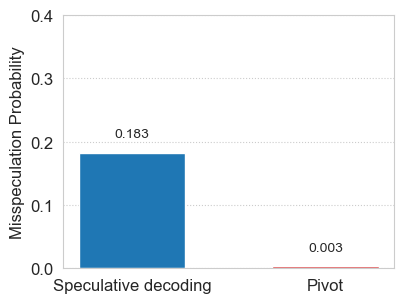

In [131]:
# ============================================================
# Bar plot
# k = 3 misspeculation probability
# x-ticks: Speculative decoding (b=1), Pivot (b=256)
# Use batch_df_all, not speculative-filtered batch_df
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

K_TARGET = 3
DATASET_FOR_BAR = None

def find_speculative_rows(df, k, dataset=None):
    sub = df.copy()
    sub = sub[
        (sub["method"].astype(str) == "speculative") &
        (sub["batch_size"] == 1) &
        (sub["num_speculative_tokens"] == k)
    ]
    if dataset is not None:
        sub = sub[sub["dataset"] == dataset]
    return sub


def find_pivot_rows(df, k, dataset=None):
    sub = df.copy()

    pivot_mask = (
        sub["method"].astype(str).str.contains("pivot", case=False, na=False) |
        sub["configuration"].astype(str).str.contains("pivot", case=False, na=False) |
        sub["record_key"].astype(str).str.contains("pivot", case=False, na=False)
    )

    sub = sub[pivot_mask]
    sub = sub[
        (sub["batch_size"] == 256) &
        (sub["num_speculative_tokens"] == k)
    ]

    if dataset is not None:
        sub = sub[sub["dataset"] == dataset]
    return sub


spec_sub = find_speculative_rows(batch_df_all, K_TARGET, dataset=DATASET_FOR_BAR)
pivot_sub = find_pivot_rows(batch_df_all, K_TARGET, dataset=DATASET_FOR_BAR)

print("Speculative matched rows:")
if len(spec_sub):
    print(spec_sub[["method", "configuration", "batch_size", "dataset", "num_speculative_tokens", "record_key"]].to_string(index=False))
else:
    print("None")

print("\nPivot matched rows:")
if len(pivot_sub):
    print(pivot_sub[["method", "configuration", "batch_size", "dataset", "num_speculative_tokens", "record_key"]].to_string(index=False))
else:
    print("None")

plot_rows = []

if len(spec_sub) > 0:
    spec_val = pd.to_numeric(spec_sub["misspeculation_probability"], errors="coerce").mean()
    plot_rows.append({
        "label": "Speculative decoding",
        "misspeculation_probability": float(spec_val),
    })
else:
    print(f"[SKIP] speculative row not found for batch_size=1, k={K_TARGET}")

if len(pivot_sub) > 0:
    pivot_val = pd.to_numeric(pivot_sub["misspeculation_probability"], errors="coerce").mean()
    plot_rows.append({
        "label": "Pivot",
        "misspeculation_probability": float(pivot_val),
    })
else:
    print(f"[SKIP] pivot row not found for batch_size=256, k={K_TARGET}")

plot_df = pd.DataFrame(plot_rows)
print("\nPlot DF:")
print(plot_df)

if len(plot_df) == 0:
    raise RuntimeError("No rows found for either speculative or pivot.")

fig, ax = plt.subplots(figsize=(4.2, 3.2))

x = np.arange(len(plot_df))
ax.bar(
    x,
    plot_df["misspeculation_probability"],
    width=0.55,
    color=[BLUE, RED][:len(plot_df)] if "BLUE" in globals() and "RED" in globals() else None,
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"])
ax.set_ylabel("Misspeculation Probability")
ax.set_ylim(0.0, 0.4)

for i, v in enumerate(plot_df["misspeculation_probability"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

title = f"k = {K_TARGET}"
if DATASET_FOR_BAR is not None:
    title += f", {DATASET_FOR_BAR}"

ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
ax.grid(False, axis="x")
plt.tight_layout()
suffix = DATASET_FOR_BAR if DATASET_FOR_BAR is not None else "avg_over_datasets"
fig.savefig(PLOTS_DIR / f"misspec_bar_k{K_TARGET}_{suffix}.pdf")
fig.savefig(PLOTS_DIR / f"misspec_bar_k{K_TARGET}_{suffix}.png", dpi=600)
plt.show()